In [1]:
# Read the pharma sales dataset
import pandas as pd

df = pd.read_csv("../data/pharma_sales.csv")

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [2]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [3]:
# Check missing values
df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [4]:
# Show summary statistics
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [5]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.columns

Index(['datum', 'm01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03',
       'r06', 'year', 'month', 'hour', 'weekday_name'],
      dtype='object')

In [6]:
# Convert date column to datetime format
df["datum"] = pd.to_datetime(df["datum"])

df[["datum"]].head()

,datum
0,2014-01-02
1,2014-01-03
2,2014-01-04
3,2014-01-05
4,2014-01-06


In [7]:
# Select medication sales columns
medicine_columns = [
    "m01ab",
    "m01ae",
    "n02ba",
    "n02be",
    "n05b",
    "n05c",
    "r03",
    "r06"
]

df[medicine_columns].head()

,m01ab,m01ae,n02ba,n02be,n05b,n05c,r03,r06
0,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0
1,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0
2,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0
3,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0
4,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0


In [8]:
# Convert dataset from wide format to long format
medicine_df = df.melt(
    id_vars=["datum", "year", "month", "hour", "weekday_name"],
    value_vars=medicine_columns,
    var_name="medicine_type",
    value_name="daily_demand"
)

medicine_df.head()

,datum,year,month,hour,weekday_name,medicine_type,daily_demand
0,2014-01-02,2014,1,248,Thursday,m01ab,0.0
1,2014-01-03,2014,1,276,Friday,m01ab,8.0
2,2014-01-04,2014,1,276,Saturday,m01ab,2.0
3,2014-01-05,2014,1,276,Sunday,m01ab,4.0
4,2014-01-06,2014,1,276,Monday,m01ab,5.0


In [9]:
# Check new dataset shape
medicine_df.shape

(16848, 7)

In [10]:
# Create simulated current stock based on daily demand
import numpy as np

np.random.seed(42)

medicine_df["current_stock"] = medicine_df["daily_demand"] * np.random.randint(
    3,
    25,
    size=len(medicine_df)
)

medicine_df.head()

,datum,year,month,hour,weekday_name,medicine_type,daily_demand,current_stock
0,2014-01-02,2014,1,248,Thursday,m01ab,0.0,0.0
1,2014-01-03,2014,1,276,Friday,m01ab,8.0,176.0
2,2014-01-04,2014,1,276,Saturday,m01ab,2.0,34.0
3,2014-01-05,2014,1,276,Sunday,m01ab,4.0,52.0
4,2014-01-06,2014,1,276,Monday,m01ab,5.0,50.0


In [11]:
# Calculate days until stockout
medicine_df["days_until_stockout"] = medicine_df["current_stock"] / medicine_df["daily_demand"].replace(0, np.nan)

medicine_df["days_until_stockout"] = medicine_df["days_until_stockout"].fillna(30)

medicine_df.head()

,datum,year,month,hour,weekday_name,medicine_type,daily_demand,current_stock,days_until_stockout
0,2014-01-02,2014,1,248,Thursday,m01ab,0.0,0.0,30.0
1,2014-01-03,2014,1,276,Friday,m01ab,8.0,176.0,22.0
2,2014-01-04,2014,1,276,Saturday,m01ab,2.0,34.0,17.0
3,2014-01-05,2014,1,276,Sunday,m01ab,4.0,52.0,13.0
4,2014-01-06,2014,1,276,Monday,m01ab,5.0,50.0,10.0


In [12]:
# Create stockout risk target
def get_stockout_risk(days):
    if days <= 3:
        return "Critical"
    elif days <= 7:
        return "High"
    elif days <= 14:
        return "Medium"
    else:
        return "Low"

medicine_df["stockout_risk"] = medicine_df["days_until_stockout"].apply(get_stockout_risk)

medicine_df["stockout_risk"].value_counts()

stockout_risk
Low         9158
Medium      4437
High        2611
Critical     642
Name: count, dtype: int64

In [13]:
# Select input features and target without data leakage
features = [
    "year",
    "month",
    "hour",
    "weekday_name",
    "medicine_type",
    "daily_demand",
    "current_stock"
]

X = medicine_df[features]
y = medicine_df["stockout_risk"]

X = pd.get_dummies(X, columns=["weekday_name", "medicine_type"], drop_first=True)

X.head()

,year,month,hour,daily_demand,current_stock,weekday_name_Monday,weekday_name_Saturday,weekday_name_Sunday,weekday_name_Thursday,weekday_name_Tuesday,weekday_name_Wednesday,medicine_type_m01ae,medicine_type_n02ba,medicine_type_n02be,medicine_type_n05b,medicine_type_n05c,medicine_type_r03,medicine_type_r06
0,2014,1,248,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2014,1,276,8.0,176.0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2014,1,276,2.0,34.0,False,True,False,False,False,False,False,False,False,False,False,False,False
3,2014,1,276,4.0,52.0,False,False,True,False,False,False,False,False,False,False,False,False,False
4,2014,1,276,5.0,50.0,True,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (13478, 18)
Testing data: (3370, 18)


In [15]:
# Scale input features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, log_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

    Critical       1.00      0.09      0.17       128
        High       0.79      0.83      0.81       522
         Low       0.89      1.00      0.94      1832
      Medium       0.91      0.78      0.84       888

    accuracy                           0.88      3370
   macro avg       0.90      0.67      0.69      3370
weighted avg       0.88      0.88      0.86      3370

Confusion Matrix:
[[  12  111    5    0]
 [   0  431   30   61]
 [   0    0 1825    7]
 [   0    3  195  690]]


In [17]:
# Train Decision Tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Results")
print(classification_report(y_test, dt_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Results
              precision    recall  f1-score   support

    Critical       0.67      0.74      0.70       128
        High       0.80      0.66      0.73       522
         Low       0.87      0.97      0.91      1832
      Medium       0.82      0.70      0.75       888

    accuracy                           0.84      3370
   macro avg       0.79      0.77      0.77      3370
weighted avg       0.84      0.84      0.83      3370

Confusion Matrix:
[[  95   23    2    8]
 [  47  347   53   75]
 [   0   10 1770   52]
 [   0   53  217  618]]


In [18]:
# Train KNN model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Results")
print(classification_report(y_test, knn_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Results
              precision    recall  f1-score   support

    Critical       0.14      0.05      0.07       128
        High       0.34      0.32      0.33       522
         Low       0.67      0.82      0.74      1832
      Medium       0.45      0.31      0.37       888

    accuracy                           0.58      3370
   macro avg       0.40      0.37      0.38      3370
weighted avg       0.54      0.58      0.55      3370

Confusion Matrix:
[[   6   42   52   28]
 [  21  165  221  115]
 [   3  137 1507  185]
 [  12  141  463  272]]


In [19]:
# Train Neural Network model
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=500,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

nn_pred = nn_model.predict(X_test_scaled)

print("Neural Network Results")
print(classification_report(y_test, nn_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, nn_pred))

Neural Network Results
              precision    recall  f1-score   support

    Critical       0.96      0.89      0.92       128
        High       0.96      0.96      0.96       522
         Low       0.99      0.99      0.99      1832
      Medium       0.97      0.98      0.97       888

    accuracy                           0.98      3370
   macro avg       0.97      0.96      0.96      3370
weighted avg       0.98      0.98      0.98      3370

Confusion Matrix:
[[ 114   14    0    0]
 [   5  502    2   13]
 [   0    0 1817   15]
 [   0    5   15  868]]


In [20]:
# Encode target labels for PyTorch
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded labels example:", y_train_encoded[:10])

Classes: ['Critical' 'High' 'Low' 'Medium']
Encoded labels example: [3 2 3 1 2 3 1 2 3 2]


In [21]:
# Convert training and testing data to PyTorch tensors
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([13478, 18])
torch.Size([13478])


In [22]:
# Build a PyTorch Neural Network model
import torch.nn as nn

class StockoutNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(StockoutNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

torch_model = StockoutNN(input_size, num_classes)

torch_model

StockoutNN(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [23]:
# Define loss function and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

In [24]:
# Train the PyTorch Neural Network model
epochs = 200

for epoch in range(epochs):
    torch_model.train()

    outputs = torch_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [20/200], Loss: 0.9642
Epoch [40/200], Loss: 0.6036
Epoch [60/200], Loss: 0.3496
Epoch [80/200], Loss: 0.2495
Epoch [100/200], Loss: 0.1902
Epoch [120/200], Loss: 0.1592
Epoch [140/200], Loss: 0.1272
Epoch [160/200], Loss: 0.1156
Epoch [180/200], Loss: 0.1001
Epoch [200/200], Loss: 0.0861


In [25]:
# Evaluate the PyTorch model
from sklearn.metrics import classification_report, confusion_matrix

torch_model.eval()

with torch.no_grad():
    test_outputs = torch_model(X_test_tensor)
    _, torch_pred_encoded = torch.max(test_outputs, 1)

torch_pred = label_encoder.inverse_transform(torch_pred_encoded.numpy())

print("PyTorch Neural Network Results")
print(classification_report(y_test, torch_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, torch_pred))

PyTorch Neural Network Results
              precision    recall  f1-score   support

    Critical       0.94      0.73      0.82       128
        High       0.92      0.95      0.93       522
         Low       0.98      0.99      0.99      1832
      Medium       0.96      0.95      0.96       888

    accuracy                           0.97      3370
   macro avg       0.95      0.91      0.93      3370
weighted avg       0.97      0.97      0.96      3370

Confusion Matrix:
[[  94   34    0    0]
 [   5  495    2   20]
 [   1    0 1816   15]
 [   0    8   32  848]]


In [26]:
# Compare model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, log_pred),
        "Precision": precision_score(y_test, log_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, log_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, log_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, dt_pred),
        "Precision": precision_score(y_test, dt_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, dt_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, dt_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, knn_pred),
        "Precision": precision_score(y_test, knn_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, knn_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, knn_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "Neural Network",
        "Accuracy": accuracy_score(y_test, nn_pred),
        "Precision": precision_score(y_test, nn_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, nn_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, nn_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "PyTorch Neural Network",
        "Accuracy": accuracy_score(y_test, torch_pred),
        "Precision": precision_score(y_test, torch_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, torch_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, torch_pred, average="weighted", zero_division=0)
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.877745,0.883118,0.877745,0.863041
1,Decision Tree,0.839763,0.837011,0.839763,0.834512
2,KNN,0.578635,0.542818,0.578635,0.551854
3,Neural Network,0.979525,0.979482,0.979525,0.979451
4,PyTorch Neural Network,0.965282,0.965171,0.965282,0.964703


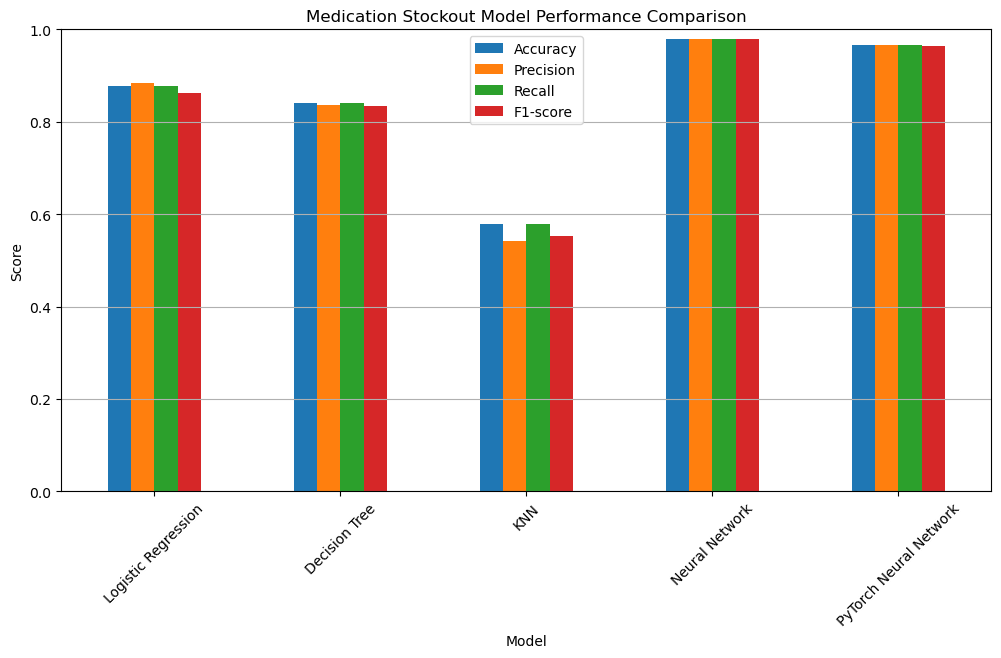

In [27]:
# Visualize final model performance comparison
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Medication Stockout Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

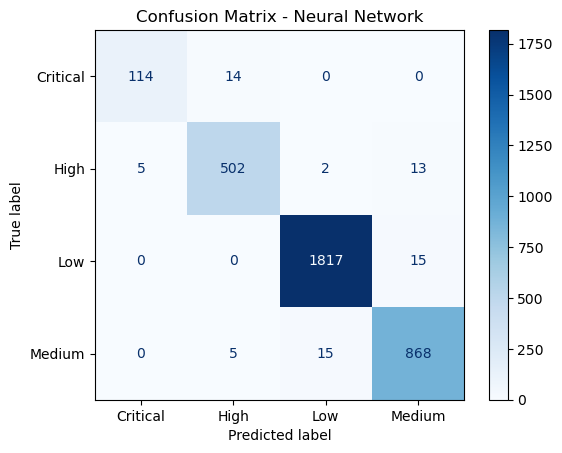

In [28]:
# Visualize confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network")
plt.show()

In [29]:
# Save the best stockout model
import joblib

joblib.dump(nn_model, "../models/stockout_model.pkl")
joblib.dump(scaler, "../models/stockout_scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/stockout_features.pkl")

['../models/stockout_features.pkl']